In [8]:
import math
import os
import types

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

from rfdetr import RFDETRMedium

transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [9]:
def load_image_as_tensor(image_path, transform, device):
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)   # [1, 3, 640, 640]
    return img_pil, img_tensor


def normalize_cam(cam, mode="negative", eps=1e-8):
    cam = cam.detach()

    if mode == "signed":
        return cam / (cam.abs().max() + eps)

    if mode == "relu":
        cam = torch.relu(cam)
        return cam / (cam.max() + eps)

    if mode == "negative":
        cam = torch.relu(-cam)
        return cam / (cam.max() + eps)

    if mode == "minmax":
        cam = cam - cam.min()
        return cam / (cam.max() + eps)

    if mode == "abs":
        cam = cam.abs()
        return cam / (cam.max() + eps)

    raise ValueError(f"Unknown normalization mode: {mode}")


def normalize_signed_cam(cam, eps=1e-8):
    cam = cam.detach()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)
    return cam


def resize_cam_to_image(cam, pil_img):
    if torch.is_tensor(cam):
        cam_t = cam.detach().cpu().float()
    else:
        cam_t = torch.tensor(cam, dtype=torch.float32)

    cam_up = F.interpolate(
        cam_t.unsqueeze(0).unsqueeze(0),
        size=(pil_img.size[1], pil_img.size[0]),
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    return cam_up


def get_heatmap_peak(cam):
    if not torch.is_tensor(cam):
        cam = torch.tensor(cam)

    cam_flat_idx = torch.argmax(cam)
    h, w = cam.shape
    y = int(cam_flat_idx // w)
    x = int(cam_flat_idx % w)
    return x, y


def coco_xywh_abs_to_rel_cxcywh(box_xywh_abs, image_width, image_height):
    x, y, w, h = box_xywh_abs
    cx = x + w / 2.0
    cy = y + h / 2.0
    return [
        cx / image_width,
        cy / image_height,
        w / image_width,
        h / image_height,
    ]


def rel_cxcywh_to_xyxy_abs(box_rel, image_width, image_height):
    cx, cy, w, h = box_rel
    x1 = (cx - w / 2.0) * image_width
    y1 = (cy - h / 2.0) * image_height
    x2 = (cx + w / 2.0) * image_width
    y2 = (cy + h / 2.0) * image_height
    return [x1, y1, x2, y2]


def box_cxcywh_to_xyxy_pixel(box, pil_img):
    w_img, h_img = pil_img.size
    cx, cy, w, h = box.tolist()
    x0 = (cx - w / 2) * w_img
    y0 = (cy - h / 2) * h_img
    x1 = (cx + w / 2) * w_img
    y1 = (cy + h / 2) * h_img
    return [x0, y0, x1, y1]


def parse_gt_box(gt_box, gt_format, pil_img):
    img_w, img_h = pil_img.size

    if gt_format == "coco_xywh_abs":
        return coco_xywh_abs_to_rel_cxcywh(gt_box, img_w, img_h)

    if gt_format == "rel_cxcywh":
        return list(gt_box)

    raise ValueError(f"Unknown gt_format: {gt_format}")


def plot_xai_result(
    pil_img,
    cam,
    gt_box_rel,
    title,
    pred_box_rel=None,
    alpha=0.45,
    cmap="jet",
    show_peak=True,
    show_gt_box=True,
    show_pred_box=False,
    save_path=None,
):
    img_np = np.array(pil_img).astype(np.float32) / 255.0
    cam_up = resize_cam_to_image(cam, pil_img)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img_np)
    ax.imshow(cam_up, cmap=cmap, alpha=alpha)

    img_w, img_h = pil_img.size

    if show_gt_box and gt_box_rel is not None:
        x1, y1, x2, y2 = rel_cxcywh_to_xyxy_abs(gt_box_rel, img_w, img_h)
        gt_rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.5,
            edgecolor="lime",
            facecolor="none",
            label="GT Box",
        )
        ax.add_patch(gt_rect)

    if show_pred_box and pred_box_rel is not None:
        if torch.is_tensor(pred_box_rel):
            pred_box_rel = pred_box_rel.detach().cpu().tolist()
        x1, y1, x2, y2 = rel_cxcywh_to_xyxy_abs(pred_box_rel, img_w, img_h)
        pred_rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.0,
            edgecolor="cyan",
            linestyle="--",
            facecolor="none",
            label="Pred Box",
        )
        ax.add_patch(pred_rect)

    if show_peak:
        peak_x, peak_y = get_heatmap_peak(torch.tensor(cam_up))
        ax.scatter(
            [peak_x], [peak_y],
            s=90,
            marker="x",
            linewidths=2.5,
        )
        ax.text(
            peak_x + 5,
            peak_y - 5,
            "Peak",
            fontsize=10,
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
        )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()
    plt.close(fig)


def select_target_query(pred_logits, target_class=0, strategy="top_score"):
    probs = pred_logits[0].softmax(-1)

    if strategy == "top_score":
        scores = probs[:, target_class]
        top_scores, top_idx = scores.sort(descending=True)
        target_query = top_idx[0].item()
        target_score = top_scores[0].item()
        return target_query, target_score

    raise ValueError(f"Unknown strategy: {strategy}")


def get_conv_gradcam(
    core_model,
    img_tensor,
    pil_img,
    target_layer=None,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="negative",
    use_box_term=False,
    box_weight=0.5,
):
    if target_layer is None:
        target_layer = core_model.backbone[0].projector.stages[0][0].cv2.conv

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_input, grad_output):
        gradients["value"] = grad_output[0]

    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    core_model.zero_grad()
    outputs = core_model(img_tensor)

    pred_logits = outputs["pred_logits"]
    pred_boxes = outputs["pred_boxes"]

    if target_query is None:
        target_query, target_score = select_target_query(
            pred_logits,
            target_class=target_class,
            strategy=query_strategy,
        )
    else:
        probs = pred_logits[0].softmax(-1)
        target_score = probs[target_query, target_class].item()

    target_logit = pred_logits[0, target_query, target_class]
    target_box = pred_boxes[0, target_query]

    if use_box_term:
        target = target_logit + box_weight * target_box.sum()
    else:
        target = target_logit

    target.backward()

    act = activations["value"]
    grad = gradients["value"]

    fwd_handle.remove()
    bwd_handle.remove()

    weights = grad.mean(dim=(2, 3), keepdim=True)
    raw_cam = (weights * act).sum(dim=1, keepdim=True)
    raw_cam_2d = raw_cam[0, 0].detach().cpu()

    cam = normalize_cam(raw_cam_2d, mode=cam_mode)

    return {
        "cam": cam.detach().cpu(),
        "raw_cam": raw_cam_2d.detach().cpu(),
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "target_box": target_box.detach().cpu(),
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }


def patch_decoder_self_attn_to_store_weights(core_model):
    patched = []

    for layer in core_model.transformer.decoder.layers:
        mha = layer.self_attn
        orig_forward = mha.forward

        def wrapped_forward(self, *args, _orig_forward=orig_forward, **kwargs):
            kwargs = dict(kwargs)
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False

            out = _orig_forward(*args, **kwargs)

            if isinstance(out, tuple) and len(out) >= 2:
                attn_output, attn_weights = out[0], out[1]
                self._last_attn_weights = attn_weights
                return attn_output, attn_weights

            self._last_attn_weights = None
            return out

        mha._orig_forward_for_rollout = orig_forward
        mha.forward = types.MethodType(wrapped_forward, mha)
        mha._last_attn_weights = None
        patched.append(mha)

    def restore_fn():
        for mha in patched:
            if hasattr(mha, "_orig_forward_for_rollout"):
                mha.forward = mha._orig_forward_for_rollout
                del mha._orig_forward_for_rollout
            if hasattr(mha, "_last_attn_weights"):
                del mha._last_attn_weights

    return restore_fn


def _normalize_attn_with_residual(attn, add_residual=True, eps=1e-8):
    q = attn.shape[0]
    if add_residual:
        attn = attn + torch.eye(q, device=attn.device, dtype=attn.dtype)
    attn = attn / (attn.sum(dim=-1, keepdim=True) + eps)
    return attn


def get_decoder_self_attn_rollout(
    core_model,
    img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    add_residual=True,
):
    restore_fn = patch_decoder_self_attn_to_store_weights(core_model)

    try:
        core_model.zero_grad()
        outputs = core_model(img_tensor)

        pred_logits = outputs["pred_logits"]
        pred_boxes = outputs["pred_boxes"]

        if target_query is None:
            target_query, target_score = select_target_query(
                pred_logits,
                target_class=target_class,
                strategy=query_strategy,
            )
        else:
            probs = pred_logits[0].softmax(-1)
            target_score = probs[target_query, target_class].item()

        target_logit = pred_logits[0, target_query, target_class]

        self_attn_maps = []
        for i, layer in enumerate(core_model.transformer.decoder.layers):
            w = getattr(layer.self_attn, "_last_attn_weights", None)
            if w is None:
                raise RuntimeError(f"Missing self-attn weights in decoder layer {i}")

            w = w[0].mean(dim=0)
            self_attn_maps.append(w.detach())

    finally:
        restore_fn()

    q = self_attn_maps[0].shape[0]
    rollout = torch.eye(q, device=self_attn_maps[0].device, dtype=self_attn_maps[0].dtype)

    for attn in self_attn_maps:
        a = _normalize_attn_with_residual(attn, add_residual=add_residual)
        rollout = a @ rollout

    query_rollout = rollout[target_query]
    query_rollout = query_rollout / (query_rollout.sum() + 1e-8)

    return {
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "query_rollout": query_rollout.detach().cpu(),
        "rollout_matrix": rollout.detach().cpu(),
        "self_attn_maps": [x.detach().cpu() for x in self_attn_maps],
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }


def _infer_num_heads_num_points(module, num_levels):
    num_heads = getattr(module, "n_heads", None)
    if num_heads is None:
        num_heads = getattr(module, "num_heads", None)
    if num_heads is None:
        num_heads = getattr(module, "n_head", None)

    num_points = getattr(module, "n_points", None)
    if num_points is None:
        num_points = getattr(module, "num_points", None)

    if num_heads is not None and num_points is not None:
        return int(num_heads), int(num_points)

    out_dim_offsets = module.sampling_offsets.out_features
    out_dim_weights = module.attention_weights.out_features

    found = []
    for h in [1, 2, 4, 8, 16, 32]:
        if out_dim_weights % (h * num_levels) == 0:
            p = out_dim_weights // (h * num_levels)
            if out_dim_offsets == h * num_levels * p * 2:
                found.append((h, p))

    if len(found) == 0:
        raise RuntimeError("Could not infer num_heads / num_points from MSDeformAttn module.")

    return found[-1]


def _compute_sampling_locations(reference_points, sampling_offsets, num_points):
    if reference_points.shape[-1] != 4:
        raise ValueError(f"Expected reference_points last dim = 4, got {reference_points.shape[-1]}")

    ref_xy = reference_points[..., :2][:, :, None, :, None, :]
    ref_wh = reference_points[..., 2:][:, :, None, :, None, :]

    sampling_locations = ref_xy + sampling_offsets / float(num_points) * ref_wh * 0.5
    return sampling_locations


def _splat_points_to_map(weights, locations, h, w):
    device = weights.device
    dtype = weights.dtype

    out = torch.zeros((h, w), device=device, dtype=dtype)

    xs = locations[:, 0] * (w - 1)
    ys = locations[:, 1] * (h - 1)

    x0 = torch.floor(xs).long().clamp(0, w - 1)
    x1 = (x0 + 1).clamp(0, w - 1)
    y0 = torch.floor(ys).long().clamp(0, h - 1)
    y1 = (y0 + 1).clamp(0, h - 1)

    dx = xs - x0.float()
    dy = ys - y0.float()

    wa = (1 - dx) * (1 - dy)
    wb = dx * (1 - dy)
    wc = (1 - dx) * dy
    wd = dx * dy

    out.index_put_((y0, x0), weights * wa, accumulate=True)
    out.index_put_((y0, x1), weights * wb, accumulate=True)
    out.index_put_((y1, x0), weights * wc, accumulate=True)
    out.index_put_((y1, x1), weights * wd, accumulate=True)

    return out


def _project_msdeform_query_to_map(attn_w_q, samp_locs_q, spatial_shapes, out_h, out_w):
    device = attn_w_q.device
    dtype = attn_w_q.dtype

    num_heads, num_levels, num_points = attn_w_q.shape
    dense = torch.zeros((out_h, out_w), device=device, dtype=dtype)

    for lvl in range(num_levels):
        h_l = int(spatial_shapes[lvl, 0].item())
        w_l = int(spatial_shapes[lvl, 1].item())

        lvl_map = torch.zeros((h_l, w_l), device=device, dtype=dtype)

        for head in range(num_heads):
            lvl_map += _splat_points_to_map(
                weights=attn_w_q[head, lvl],
                locations=samp_locs_q[head, lvl],
                h=h_l,
                w=w_l,
            )

        lvl_map_up = F.interpolate(
            lvl_map[None, None],
            size=(out_h, out_w),
            mode="bilinear",
            align_corners=False,
        )[0, 0]

        dense += lvl_map_up

    return dense


def get_decoder_self_cross_rollout_map(
    core_model,
    img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="relu",
    add_self_attn_residual=True,
):
    device = img_tensor.device
    img_h, img_w = int(img_tensor.shape[-2]), int(img_tensor.shape[-1])

    self_result = get_decoder_self_attn_rollout(
        core_model=core_model,
        img_tensor=img_tensor,
        target_class=target_class,
        target_query=target_query,
        query_strategy=query_strategy,
        add_residual=add_self_attn_residual,
    )

    target_query = self_result["target_query"]
    query_rollout = self_result["query_rollout"].to(device)

    saved_cross = []
    handles = []

    def make_cross_hook(layer_idx):
        def cross_hook(module, inp, out):
            record = {"layer": layer_idx}

            query = inp[0]
            reference_points = inp[1]
            spatial_shapes = inp[3]

            b, q, c = query.shape
            num_levels = spatial_shapes.shape[0]

            num_heads, num_points = _infer_num_heads_num_points(module, num_levels)

            sampling_offsets = module.sampling_offsets(query)
            attention_weights = module.attention_weights(query)

            sampling_offsets = sampling_offsets.view(
                b, q, num_heads, num_levels, num_points, 2
            )

            attention_weights = attention_weights.view(
                b, q, num_heads, num_levels, num_points
            )
            attention_weights = F.softmax(
                attention_weights.view(b, q, num_heads, -1), dim=-1
            ).view(b, q, num_heads, num_levels, num_points)

            sampling_locations = _compute_sampling_locations(
                reference_points=reference_points,
                sampling_offsets=sampling_offsets,
                num_points=num_points,
            )

            record["attention_weights"] = attention_weights.detach()
            record["sampling_locations"] = sampling_locations.detach()
            record["spatial_shapes"] = spatial_shapes.detach()
            saved_cross.append(record)

        return cross_hook

    try:
        for i, layer in enumerate(core_model.transformer.decoder.layers):
            handles.append(layer.cross_attn.register_forward_hook(make_cross_hook(i)))

        outputs = core_model(img_tensor)
        pred_logits = outputs["pred_logits"]
        pred_boxes = outputs["pred_boxes"]

    finally:
        for h in handles:
            h.remove()

    q_total = pred_logits.shape[1]
    per_query_map = torch.zeros((q_total, img_h, img_w), device=device, dtype=img_tensor.dtype)

    saved_cross = sorted(saved_cross, key=lambda x: x["layer"])

    for rec in saved_cross:
        attn_w = rec["attention_weights"][0]
        samp_l = rec["sampling_locations"][0]
        spatial_shapes = rec["spatial_shapes"]

        layer_maps = []
        for q_idx in range(q_total):
            q_map = _project_msdeform_query_to_map(
                attn_w_q=attn_w[q_idx],
                samp_locs_q=samp_l[q_idx],
                spatial_shapes=spatial_shapes,
                out_h=img_h,
                out_w=img_w,
            )
            layer_maps.append(q_map)

        layer_maps = torch.stack(layer_maps, dim=0)
        per_query_map += layer_maps

    per_query_map = per_query_map / max(len(saved_cross), 1)

    raw_rollout_map = (query_rollout[:, None, None] * per_query_map).sum(dim=0)
    rollout_map = normalize_cam(raw_rollout_map, mode=cam_mode)

    return {
        "rollout_map": rollout_map.detach().cpu(),
        "raw_rollout_map": raw_rollout_map.detach().cpu(),
        "query_rollout": query_rollout.detach().cpu(),
        "per_query_map": per_query_map.detach().cpu(),
        "target_query": target_query,
        "target_class": self_result["target_class"],
        "target_score": self_result["target_score"],
        "target_logit": self_result["target_logit"],
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }


def box_cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)


def box_iou_xyxy(boxes1, boxes2):
    area1 = ((boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) *
             (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0))
    area2 = ((boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) *
             (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0))

    lt = torch.max(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[None, :, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]

    union = area1[:, None] + area2[None, :] - inter
    return inter / (union + 1e-8)


def select_target_detection(outputs, target_class=None, target_query=None, query_strategy="top_score"):
    pred_logits = outputs["pred_logits"]
    pred_boxes = outputs["pred_boxes"]

    logits0 = pred_logits[0]

    if target_query is None:
        if query_strategy == "top_score":
            if target_class is None:
                q = int(logits0.max(dim=-1).values.argmax().item())
                c = int(logits0[q].argmax().item())
            else:
                q = int(logits0[:, target_class].argmax().item())
                c = int(target_class)
        else:
            raise ValueError(f"Unknown query_strategy: {query_strategy}")
    else:
        q = int(target_query)
        c = int(logits0[q].argmax().item()) if target_class is None else int(target_class)

    score = logits0[q].softmax(dim=-1)[c]
    box = pred_boxes[0, q]

    return {
        "target_query": q,
        "target_class": c,
        "target_score": score.detach(),
        "target_box": box.detach(),
        "pred_logits": pred_logits.detach(),
        "pred_boxes": pred_boxes.detach(),
    }


def generate_drise_mask(image_h, image_w, grid_h=16, grid_w=16, p1=0.5, device="cpu"):
    cell_h = math.ceil(image_h / grid_h)
    cell_w = math.ceil(image_w / grid_w)

    small = (torch.rand((1, 1, grid_h, grid_w), device=device) < p1).float()

    up_h = (grid_h + 1) * cell_h
    up_w = (grid_w + 1) * cell_w

    up = F.interpolate(small, size=(up_h, up_w), mode="bilinear", align_corners=False)[0, 0]

    shift_y = torch.randint(0, cell_h, (1,), device=device).item()
    shift_x = torch.randint(0, cell_w, (1,), device=device).item()

    mask = up[shift_y:shift_y + image_h, shift_x:shift_x + image_w]
    return mask


def match_score_for_target(masked_outputs, target_class, target_box, score_power=1.0, iou_power=1.0):
    pred_logits = masked_outputs["pred_logits"][0]
    pred_boxes = masked_outputs["pred_boxes"][0]

    class_probs = pred_logits.softmax(dim=-1)[:, target_class]

    target_xyxy = box_cxcywh_to_xyxy(target_box[None])
    pred_xyxy = box_cxcywh_to_xyxy(pred_boxes)
    ious = box_iou_xyxy(target_xyxy, pred_xyxy)[0]

    scores = (class_probs.clamp(min=0) ** score_power) * (ious.clamp(min=0) ** iou_power)
    best_idx = int(scores.argmax().item())
    best_score = scores[best_idx]

    return {
        "best_score": best_score,
        "best_idx": best_idx,
        "best_class_prob": class_probs[best_idx].detach(),
        "best_iou": ious[best_idx].detach(),
        "all_scores": scores.detach(),
    }


def get_drise_map(
    core_model,
    img_tensor,
    target_class=None,
    target_query=None,
    query_strategy="top_score",
    num_masks=1000,
    grid_h=16,
    grid_w=16,
    p1=0.5,
    batch_size=16,
    score_power=1.0,
    iou_power=1.0,
    cam_mode="relu",
):
    device = img_tensor.device
    _, _, H, W = img_tensor.shape

    with torch.inference_mode():
        outputs = core_model(img_tensor)

    target_info = select_target_detection(
        outputs,
        target_class=target_class,
        target_query=target_query,
        query_strategy=query_strategy,
    )

    target_class = target_info["target_class"]
    target_query = target_info["target_query"]
    target_box = target_info["target_box"]

    saliency = torch.zeros((H, W), device=device, dtype=img_tensor.dtype)
    masks_buffer = []

    def process_batch(mask_batch):
        nonlocal saliency

        with torch.inference_mode():
            masked_imgs = img_tensor * mask_batch[:, None, :, :]
            outputs_b = core_model(masked_imgs)
            pred_logits_b = outputs_b["pred_logits"]
            pred_boxes_b = outputs_b["pred_boxes"]

            for i in range(mask_batch.shape[0]):
                masked_outputs_i = {
                    "pred_logits": pred_logits_b[i:i+1],
                    "pred_boxes": pred_boxes_b[i:i+1],
                }

                match = match_score_for_target(
                    masked_outputs_i,
                    target_class=target_class,
                    target_box=target_box,
                    score_power=score_power,
                    iou_power=iou_power,
                )

                saliency += match["best_score"] * mask_batch[i]

        del masked_imgs, outputs_b, pred_logits_b, pred_boxes_b

    for _ in range(num_masks):
        mask = generate_drise_mask(
            image_h=H,
            image_w=W,
            grid_h=grid_h,
            grid_w=grid_w,
            p1=p1,
            device=device,
        )
        masks_buffer.append(mask)

        if len(masks_buffer) == batch_size:
            batch = torch.stack(masks_buffer, dim=0)
            process_batch(batch)
            masks_buffer = []

    if len(masks_buffer) > 0:
        batch = torch.stack(masks_buffer, dim=0)
        process_batch(batch)

    raw_map = saliency / (num_masks * p1 + 1e-8)
    drise_map = normalize_cam(raw_map, mode=cam_mode)

    return {
        "drise_map": drise_map.detach().cpu(),
        "raw_drise_map": raw_map.detach().cpu(),
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_info["target_score"].cpu(),
        "target_box": target_box.cpu(),
        "pred_logits": target_info["pred_logits"].cpu(),
        "pred_boxes": target_info["pred_boxes"].cpu(),
    }

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "checkpoint_best_total (2).pth"

model = RFDETRMedium(
    pretrain_weights=model_path,
    device=device,
)

core_model = model.model.model.to(device)
core_model.eval()

print("Model loaded on:", device)

[2026-03-22 15:01:53] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-22 15:01:53] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-22 15:01:53] [INFO] rf-detr - Loading pretrain weights


[2026-03-22 15:01:53] [WARNING] rf-detr - Reinitializing detection head with 1 classes based on pretrained weights, configured for 90.


Model loaded on: cuda


In [11]:
image_path = "A0007_1.3.6.1.4.1.14519.5.2.1.6655.2359.118972525676913596910705207496_16bit.png"

# deine GT-Box im COCO-Format: x, y, w, h
gt_box_abs = [
    328.000244140625,
    309.00018310546875,
    66.99981689453125,
    72.99993896484375,
]

pil_img, img_tensor = load_image_as_tensor(image_path, transform, device)

img_w, img_h = pil_img.size
gt_box_rel = coco_xywh_abs_to_rel_cxcywh(gt_box_abs, img_w, img_h)

print("Original image size:", pil_img.size)
print("GT box rel:", gt_box_rel)

Original image size: (512, 512)
GT box rel: [0.7060549855232239, 0.6748049855232239, 0.13085901737213135, 0.14257800579071045]


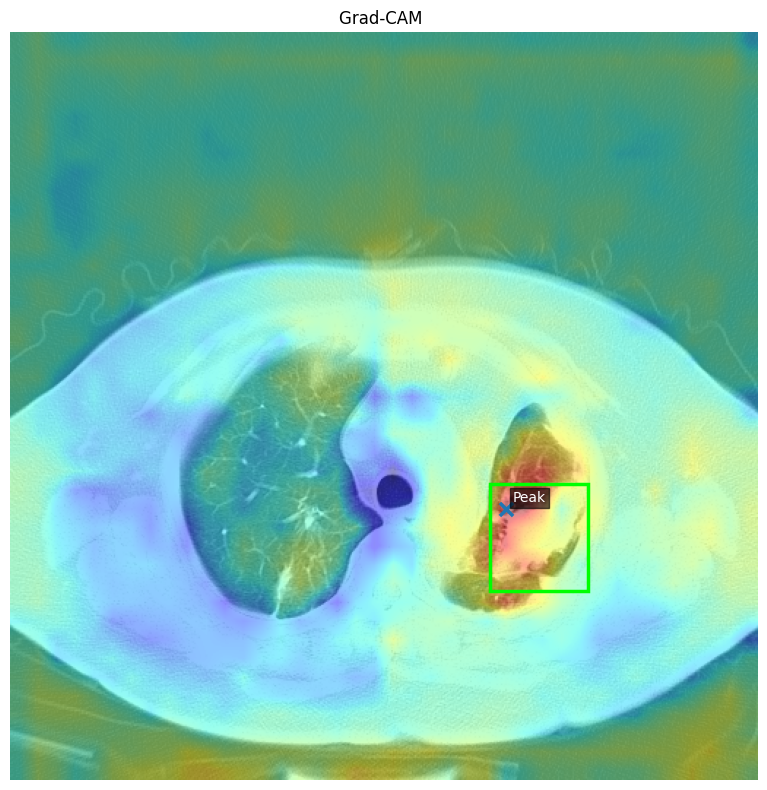

In [12]:
gradcam_result = get_conv_gradcam(
    core_model=core_model,
    img_tensor=img_tensor,
    pil_img=pil_img,
    target_layer=core_model.backbone[0].projector.stages[0][0].cv2.conv,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="negative",
    use_box_term=False,
    box_weight=0.5,
)

gradcam_cam = normalize_signed_cam(gradcam_result["cam"])

plot_xai_result(
    pil_img=pil_img,
    cam=gradcam_cam,
    gt_box_rel=gt_box_rel,
    pred_box_rel=gradcam_result["target_box"],
    title="Grad-CAM ",
    cmap="jet",
    show_peak=True,
    show_gt_box=True,
    show_pred_box=False,
)

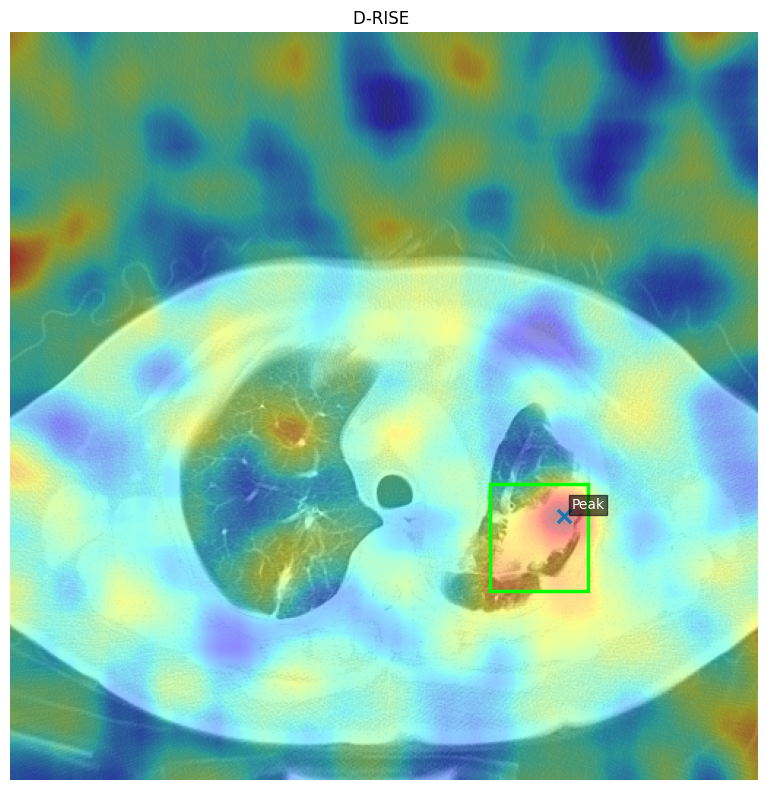

In [16]:
drise_result = get_drise_map(
    core_model=core_model,
    img_tensor=img_tensor,
    num_masks=1028,
    grid_h=16,
    grid_w=16,
    p1=0.5,
    batch_size=16,
    iou_power=2.0,
)

plot_xai_result(
    pil_img=pil_img,
    cam=drise_result["drise_map"],
    gt_box_rel=gt_box_rel,
    pred_box_rel=drise_result["target_box"],
    title="D-RISE ",
    cmap="jet",
    show_peak=True,
    show_gt_box=True,
    show_pred_box=False,
)

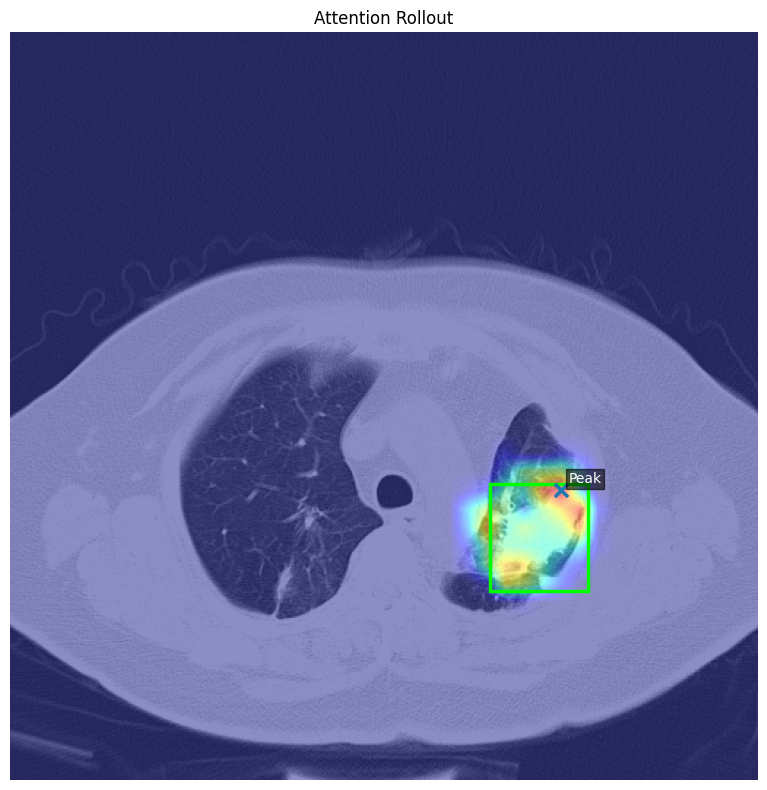

In [14]:
rollout_result = get_decoder_self_cross_rollout_map(
    core_model=core_model,
    img_tensor=img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="minmax",
    add_self_attn_residual=True,
)

target_query = rollout_result["target_query"]
direct_map = rollout_result["per_query_map"][target_query]
direct_map_norm = direct_map - direct_map.min()
direct_map_norm = direct_map_norm / (direct_map_norm.max() + 1e-8)

plot_xai_result(
    pil_img=pil_img,
    cam=direct_map_norm,
    gt_box_rel=gt_box_rel,
    pred_box_rel=rollout_result["pred_boxes"][0, target_query],
    title="Attention Rollout",
    cmap="jet",
    show_peak=True,
    show_gt_box=True,
    show_pred_box=False,
)